# Тема 5. Ансамблевые методы и случайный лес

## Занятие 5 (теория)

**В теме 3 одно дерево решений дало 93-94% на данных оттока.** Но у дерева есть слабое место: оно неустойчиво — чуть другой набор обучающих примеров, и дерево может получиться заметно другим. Сегодня проверим это на практике и увидим, что объединение **многих** неустойчивых деревьев в одну модель (ансамбль) не только стабильнее, но и точнее.

**План занятия:** неустойчивость одного дерева → бутстрап и бэггинг → случайный лес → OOB-ошибка как бесплатная валидация → важность признаков → плюсы/минусы.

**Практика** — в `lesson05_ensembles_practice.ipynb` (Titanic — лес против дерева темы 3).
**Дополнительно** (теорема Кондорсе, ExtraTrees, `GridSearchCV`, важность через перестановки) — в `lesson05_ensembles_advanced.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Одно дерево неустойчиво

Возьмём один и тот же датасет оттока, но 5 раз обучим дерево на **разных случайных подвыборках** (с возвращением — *бутстрап*, об этом чуть подробнее дальше) и посмотрим, одинаково ли деревья предсказывают одних и тех же 5 клиентов.

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)

X = df.drop(columns=["State", "Churn"])
y = df["Churn"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

rng = np.random.RandomState(RANDOM_STATE)
sample_points = X_valid.iloc[:5]
for i in range(5):
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_train.iloc[idx], y_train.iloc[idx])
    print(f"дерево {i+1}:", tree.predict(sample_points))
print("реальные метки:  ", y_valid.iloc[:5].values)

дерево 1: [0 1 0 0 0]
дерево 2: [0 1 0 0 0]
дерево 3: [0 1 0 0 0]
дерево 4: [0 1 0 1 0]
дерево 5: [0 1 0 0 0]
реальные метки:   [0 1 0 0 0]


Деревья почти всегда сходятся, но не всегда — на некоторых клиентах голоса расходятся. Каждое дерево по отдельности «уверено», но уверено по-разному. **Идея бэггинга**: раз одно дерево иногда ошибается в одну сторону, а другое — в другую, усреднение (или голосование большинством) их предсказаний должно быть точнее и стабильнее, чем любое дерево по отдельности.

### Бутстрап

**Бутстрап** — способ получить много «немного разных» выборок из одной: случайно выбираем $n$ объектов **с возвращением** из исходных $n$ (некоторые объекты попадут несколько раз, некоторые — ни разу, в среднем ~63% уникальных объектов на выборку). Так мы и получили 5 разных деревьев выше.

### Бэггинг (Bootstrap Aggregating)

Обучаем много моделей на бутстрап-выборках и усредняем их предсказания (голосование — для классификации, среднее — для регрессии). Работает для любой неустойчивой модели, но особенно хорошо — для деревьев.

---
## 2. Случайный лес

**Случайный лес** — бэггинг над деревьями решений с одним важным добавлением: при поиске лучшего расщепления в каждом узле дерево смотрит не на все признаки, а на **случайное подмножество**. Без этого шага деревья бы получались слишком похожими друг на друга (если один признак явно сильнее всех — почти каждое дерево начало бы с него), а нам нужно, чтобы деревья ошибались **по-разному** — тогда усреднение реально помогает.

**Задание преподавателю на занятии:** обучите `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)` на `X_train`/`y_train`, сравните `.score()` на `X_valid` с деревом из темы 3 (93-94%).

In [ ]:
# rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
# rf.fit(X_train, y_train)
# rf.score(X_valid, y_valid)


In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
round(rf.score(X_valid, y_valid), 4)

0.951

**95.1%** — лучше одного дерева (93-94%). Ансамбль не просто стабильнее, он ещё и точнее — усреднение сглаживает индивидуальные ошибки отдельных деревьев.

---
## 3. Out-of-bag ошибка: бесплатная валидация

У бутстрапа есть приятное следствие: каждое дерево видит только ~63% исходных данных, а оставшиеся ~37% («out-of-bag», OOB) для этого дерева — не обучающие. Можно проверять каждое дерево на его же OOB-объектах и усреднить — получаем оценку качества **без отдельной валидационной выборки и без кросс-валидации**, почти бесплатно.

In [4]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
rf_oob.fit(X, y)  # обучаем на всех данных сразу — OOB сам умеет честно валидироваться

cv_score = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X, y, cv=5
).mean()

print(f"OOB-точность:         {rf_oob.oob_score_:.4f}")
print(f"CV-точность (5-fold): {cv_score:.4f}")

OOB-точность:         0.9562
CV-точность (5-fold): 0.9562


Оценки почти совпадают — OOB работает как полноценная замена кросс-валидации, но не требует заново обучать модель `k` раз. Полезно, когда лес большой и кросс-валидация была бы дорогой.

---
## 4. Важность признаков — ещё раз, но стабильнее

Как и у одного дерева, у леса есть `feature_importances_` — только теперь это усреднение по всем деревьям, а значит, устойчивее к случайностям одной конкретной обучающей выборки.

**Прежде чем смотреть — угадайте:** останется ли тройка лидеров той же, что была у одного дерева в теме 3 (`Total day charge`/`minutes`, `Customer service calls`)?

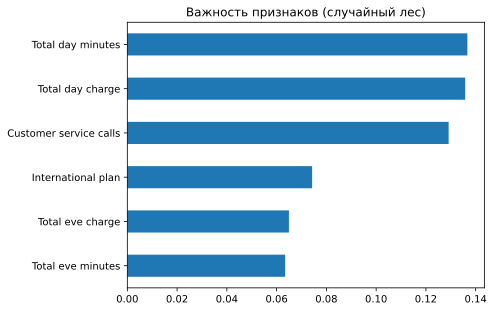

In [5]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.tail(6).plot(kind="barh", title="Важность признаков (случайный лес)");

Та же тройка лидеров, что и у одного дерева в теме 3 — но лес увереннее в ранжировании: важности распределены более гладко (не один признак резко доминирует), потому что усреднены по 200 деревьям, каждое из которых видело свой случайный поднабор признаков в каждом узле.

---
## 5. Ключевые параметры

- `n_estimators` — число деревьев. Больше — обычно лучше (до плато), но дольше считать; переобучение от роста `n_estimators` практически не грозит (в отличие от `max_depth` одного дерева).
- `max_depth`, `min_samples_leaf` — те же параметры, что у одного дерева, только теперь для каждого дерева в лесу.
- `max_features` — сколько признаков рассматривать при поиске расщепления (по умолчанию $\sqrt{d}$ для классификации). Меньше — деревья более разные (лучше декоррелированы), но каждое по отдельности слабее.

---
## 6. Плюсы и минусы

| Плюсы | Минусы |
|---|---|
| Точнее и стабильнее одного дерева | Менее интерпретируем — «дерево» из 200 деревьев не нарисуешь и не объяснишь одним взглядом |
| Почти не переобучается от роста `n_estimators` | Медленнее в предсказании (нужно опросить все деревья) |
| `feature_importances_` и OOB — «бесплатные» бонусы | Занимает больше памяти (хранит много деревьев) |
| Хорошо работает «из коробки», минимум настройки | На задачах с явной последовательной структурой (или где нужна максимальная точность) часто проигрывает бустингу — тема 8 |

---
## Итог занятия

Сегодня разобрали:

- Почему одно дерево неустойчиво и как усреднение многих деревьев это лечит
- Бутстрап и бэггинг
- Случайный лес = бэггинг + случайное подмножество признаков на каждом расщеплении
- OOB-ошибку как бесплатную альтернативу кросс-валидации
- `feature_importances_` леса — более стабильную версию того же, что было у дерева

**Текущий счёт на данных оттока:**

| Подход | Точность |
|---|---|
| Ручное правило (тема 1) | 85.8% |
| Логистическая регрессия (тема 4) | 86.5% |
| Дерево решений (тема 3) | 93-94% |
| Случайный лес (тема 5) | 95.1% |

**Дальше:**
- Практика — `lesson05_ensembles_practice.ipynb` (Titanic: лес против дерева)
- Доп. материалы — `lesson05_ensembles_advanced.ipynb`
- Следующее занятие — конструирование и отбор признаков